# Loading Dataset

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'diabetic_data.csv')

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes


# Data Understanding / Problem Definition

In [ ]:
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (101766, 50)


In [ ]:
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          

In [ ]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
df.dtypes

,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [ ]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Defining Target Variable:
   
   {Early readmission (<30) = 1
    
    Otherwise = 0}


In [ ]:
print("Unique Values in Readmitted Column before Mapping:",df['readmitted'].unique())

readmission_map = {     #mapping
    'NO': 0,
    '>30': 0,
    '<30': 1
}
df['early_readmission'] = df['readmitted'].map(readmission_map)

print(df[['readmitted', 'early_readmission']].head(20))

print("\n\nUnique Values in Target Column after Mapping:",df['early_readmission'].unique())

print(df['early_readmission'].value_counts())

Unique Values in Readmitted Column before Mapping: ['NO' '>30' '<30']
   readmitted  early_readmission
0          NO                  0
1         >30                  0
2          NO                  0
3          NO                  0
4          NO                  0
5         >30                  0
6          NO                  0
7         >30                  0
8          NO                  0
9          NO                  0
10        >30                  0
11        <30                  1
12        <30                  1
13         NO                  0
14        >30                  0
15         NO                  0
16        <30                  1
17         NO                  0
18        >30                  0
19         NO                  0


Unique Values in Target Column after Mapping: [0 1]
early_readmission
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
df.drop(columns=['readmitted'], inplace=True)

# Data Cleaning

In [ ]:
import pandas as pd
import numpy as np

# Replace '?' with null in the entire dataset
df.replace('?', np.nan, inplace=True)

#print(df['weight'])

# Check total missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Dropping Columns

In [ ]:
#removing weight column
df.drop(columns=['weight'], inplace=True)

#removing payer code
df.drop(columns=['payer_code'], inplace=True)

#removing encounter id
df.drop(columns=['encounter_id'], inplace=True)

#removing patient number
df.drop(columns=['patient_nbr'], inplace=True)

Handling Missing Value

In [ ]:
print(df['race'].isnull().sum())  # Before
df['race'] = df['race'].fillna('Unknown')
print(df['race'].isnull().sum())  # After

2273
0


In [ ]:
df['race'].unique()

array(['Caucasian', 'AfricanAmerican', 'Unknown', 'Other', 'Asian',
       'Hispanic'], dtype=object)

In [ ]:
df['medical_specialty'].isna().sum()

np.int64(49949)

In [ ]:
df['medical_specialty'].value_counts()

,count
medical_specialty,
InternalMedicine,14635
Emergency/Trauma,7565
Family/GeneralPractice,7440
Cardiology,5352
Surgery-General,3099
...,...
Proctology,1
Speech,1
SportsMedicine,1


In [ ]:
# covert missing values
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

In [ ]:
df['age'].isnull().sum()

np.int64(0)

# Feature Engineering

In [ ]:
# Mapping ICD codes to disease groups

def map_icd_group(code):

  #handle null values
  if pd.isna(code):
    return "Unknown"

  code = str(code)

  # V-codes
  if code.startswith('V'):
    return 'External/Other'

  # Convert intro float

  try:
    code_num = float(code)
  except ValueError:
    return 'Unknown'

  # Now, map to common ICD Groups
  if 390 <= code_num <= 459:
    return 'Circulatory'
  elif 460 <= code_num <= 519:
    return 'Respiratory'
  elif 520 <= code_num <= 579:
    return 'Digestive'
  elif 250 <= code_num < 251:
    return 'Diabetes'
  else:
    return 'Other'

df['diag_1'] = df['diag_1'].map(map_icd_group)
df['diag_2'] = df['diag_2'].map(map_icd_group)
df['diag_3'] = df['diag_3'].map(map_icd_group)

In [ ]:
df['medical_specialty'].unique()

array(['Pediatrics-Endocrinology', 'Unknown', 'InternalMedicine',
       'Family/GeneralPractice', 'Cardiology', 'Surgery-General',
       'Orthopedics', 'Gastroenterology',
       'Surgery-Cardiovascular/Thoracic', 'Nephrology',
       'Orthopedics-Reconstructive', 'Psychiatry', 'Emergency/Trauma',
       'Pulmonology', 'Surgery-Neuro',
       'Obsterics&Gynecology-GynecologicOnco', 'ObstetricsandGynecology',
       'Pediatrics', 'Hematology/Oncology', 'Otolaryngology',
       'Surgery-Colon&Rectal', 'Pediatrics-CriticalCare', 'Endocrinology',
       'Urology', 'Psychiatry-Child/Adolescent', 'Pediatrics-Pulmonology',
       'Neurology', 'Anesthesiology-Pediatric', 'Radiology',
       'Pediatrics-Hematology-Oncology', 'Psychology', 'Podiatry',
       'Gynecology', 'Oncology', 'Pediatrics-Neurology',
       'Surgery-Plastic', 'Surgery-Thoracic',
       'Surgery-PlasticwithinHeadandNeck', 'Ophthalmology',
       'Surgery-Pediatric', 'Pediatrics-EmergencyMedicine',
       'PhysicalMedicin

In [ ]:
# Grouping Clinically Meaningful sub-groups

spec_counts = df['medical_specialty'].value_counts()

medicine = [
    "InternalMedicine", "Family/GeneralPractice", "Hospitalist",
    "Endocrinology", "Nephrology", "Pulmonology", "Rheumatology",
    "InfectiousDiseases"
]

surgery = [
    "Surgery-General", "Surgery-Cardiovascular",
    "Surgery-Vascular", "Surgery-Neuro",
    "Surgery-Plastic", "Surgery-Thoracic"
]

emergency = ["Emergency/Trauma"]

cardio = ["Cardiology", "Cardiology-Pediatric"]

psych = ["Psychiatry", "Psychology", "Psychiatry-Child/Adolescent"]

peds = [s for s in spec_counts.index if s.startswith("Pediatrics")]

# Mapping Function
def map_specialty(spec):
    if spec == "Unknown":
        return "Unknown"
    if spec in medicine:
        return "Medicine"
    if spec in surgery:
        return "Surgery"
    if spec in emergency:
        return "Emergency"
    if spec in cardio:
        return "Cardiology"
    if spec in psych:
        return "Psychiatry"
    if spec in peds:
        return "Pediatrics"
    return "Other"

In [ ]:
df["medical_specialty_grouped"] = df["medical_specialty"].apply(map_specialty)

In [ ]:
df['medical_specialty_grouped'].value_counts()

,count
medical_specialty_grouped,
Unknown,49949
Medicine,24790
Other,8247
Emergency,7565
Cardiology,5359
Surgery,4348
Psychiatry,962
Pediatrics,546


In [ ]:
df["medical_specialty_grouped"].value_counts(normalize=True)

,proportion
medical_specialty_grouped,
Unknown,0.490822
Medicine,0.243598
Other,0.081039
Emergency,0.074337
Cardiology,0.052660
Surgery,0.042725
Psychiatry,0.009453
Pediatrics,0.005365


In [ ]:
df.drop(columns=['medical_specialty'], inplace=True)

### **AGE** Column

In [ ]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95       #Mean/Midpoint Values
}
df['age'] = df['age'].map(age_map)

In [ ]:
df['age'].value_counts()

,count
age,
75,26068
65,22483
55,17256
85,17197
45,9685
35,3775
95,2793
25,1657
15,691


### **AC1Result Column**

In [ ]:
df['A1Cresult'].value_counts()

,count
A1Cresult,
>8,8216
Norm,4990
>7,3812


In [ ]:
df['A1Cresult'].unique()

array([nan, '>7', '>8', 'Norm'], dtype=object)

In [ ]:
# 0 = Not measured (Baseline)
# 1 = Normal
# 2 = High (>7)
a1c_map = {'>8': 2, '>7': 2, 'Norm': 1}

In [ ]:
df['A1C_measured'] = df['A1Cresult'].notna().astype(int)
df['A1C_level'] = df['A1Cresult'].map(a1c_map)
df['A1C_level'] = df['A1C_level'].fillna(0)

In [ ]:
df['A1C_measured'].isnull().sum()

np.int64(0)

In [ ]:
df['A1C_level'].value_counts()

,count
A1C_level,
0.0,84748
2.0,12028
1.0,4990


In [ ]:
df.drop(columns=['A1Cresult'], inplace=True)

### Medication variables:
   Convert multiple medication indicators into:

*   “Medication used (yes/no)”
*   OR “Medication (change/ no change)”

(see dataset and decide and do accordingly)





In [ ]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,early_readmission,medical_specialty_grouped,A1C_measured,A1C_level
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,0,Pediatrics,0,0.0
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,No,No,No,Ch,Yes,0,Unknown,0,0.0
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,Yes,0,Unknown,0,0.0
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,No,No,No,Ch,Yes,0,Unknown,0,0.0
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,No,No,No,Ch,Yes,0,Unknown,0,0.0


Medicinal summaries are already present in dataset:
*  diabetes_med: tells if medicine was used (yes/no)

*  change: tells if medicine dosage was change (yes/no)

 Hence, we drop all individual 23 Medicine Columns

In [ ]:
med_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df = df.drop(columns=med_columns)

print(df.columns)

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'change',
       'diabetesMed', 'early_readmission', 'medical_specialty_grouped',
       'A1C_measured', 'A1C_level'],
      dtype='object')


In [ ]:
print(df['change'].value_counts())

print("\n", df['diabetesMed'].value_counts())

change
No    54755
Ch    47011
Name: count, dtype: int64

 diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


In [ ]:
# convert into binary
df['change'] = df['change'].map({'Ch': 1, 'No': 0})
df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})

print(df['change'].value_counts())

print("\n", df['diabetesMed'].value_counts())

change
0    54755
1    47011
Name: count, dtype: int64

 diabetesMed
1    78363
0    23403
Name: count, dtype: int64


## REMAINING COLUMNS

In [ ]:
df.shape

(101766, 24)

In [ ]:
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'change',
       'diabetesMed', 'early_readmission', 'medical_specialty_grouped',
       'A1C_measured', 'A1C_level'],
      dtype='object')

In [ ]:
df.dtypes

,0
race,object
gender,object
age,int64
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
num_lab_procedures,int64
num_procedures,int64
num_medications,int64


In [ ]:
df['max_glu_serum'].unique()

array([nan, '>300', 'Norm', '>200'], dtype=object)

In [ ]:
# max_glu_serum ==> max glucose found in blood
print(df['max_glu_serum'].value_counts(), "\n\nTotal null values present in max_glu_serum: ", df['max_glu_serum'].isnull().sum())

glu_map = {'Norm': 1, '>200': 2, '>300': 3}
df['max_glu_serum_level'] = df['max_glu_serum'].map(glu_map)
df['max_glu_serum_measured'] = df['max_glu_serum'].notna().astype(int)
df['max_glu_serum_level'] = df['max_glu_serum_level'].fillna(0)
df.drop(columns=['max_glu_serum'], inplace=True)

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64 

Total null values present in max_glu_serum:  96420


In [ ]:
# admission type
print(df['admission_type_id'].value_counts(), "\nNull values present: ", df['admission_type_id'].isnull().sum())
admission_type_map = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    6: 'Newborn'
}

df['admission_type_grouped'] = df['admission_type_id'].map(admission_type_map).fillna('Other')
df.drop(columns=['admission_type_id'], inplace=True)

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64 
Null values present:  0


In [ ]:
# discharge disposition ==> code for discharge status (eg., such as being discharged to home, expired, or transferred to another facility)
print( df['discharge_disposition_id'].value_counts(), "\nNumber of null values present: ", df['discharge_disposition_id'].isnull().sum())
death_ids = [11]
home_ids = [1]
transfer_ids = [3, 6, 18, 22, 23, 24, 25]
other_ids = [2,4,5,7,8,9,10,12,13,14,15,16,17,19,20,27,28]

def map_discharge(x):
    if x in home_ids:
        return 'Home'
    elif x in transfer_ids:
        return 'Transfer'
    elif x in death_ids:
        return 'Expired'
    else:
        return 'Other'

df['discharge_grouped'] = df['discharge_disposition_id'].apply(map_discharge)

#drop discharge == expired
df = df[df['discharge_grouped'] != 'Expired']
df.drop(columns=['discharge_disposition_id', 'discharge_grouped'], inplace=True)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64 
Number of null values present:  0


In [ ]:
# admission source id ==> code that maps to specific admission sources such as referrals, another facility, etc
print(df['admission_source_id'].value_counts(), "\nnull value present: ", df['admission_source_id'].isnull().sum())

admission_source_map = {
    7: 'Emergency_Room',
    1: 'Physician_Referral',
    17: 'Transfer'
}

df['admission_source_grouped'] = df['admission_source_id'].map(admission_source_map).fillna('Other')
df.drop(columns=['admission_source_id'], inplace=True)

admission_source_id
7     56370
1     29324
17     6646
4      3132
6      2244
2      1083
5       814
3       185
20      159
9       125
8        15
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64 
null value present:  0


In [ ]:
df['admission_source_grouped'].unique()

array(['Physician_Referral', 'Emergency_Room', 'Other', 'Transfer'],
      dtype=object)

In [ ]:
df.columns

Index(['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'change', 'diabetesMed', 'early_readmission',
       'medical_specialty_grouped', 'A1C_measured', 'A1C_level',
       'max_glu_serum_level', 'max_glu_serum_measured',
       'admission_type_grouped', 'admission_source_grouped'],
      dtype='object')

In [ ]:
print(df['gender'].value_counts())
df['gender'].isnull().sum()

gender
Female             53866
Male               46255
Unknown/Invalid        3
Name: count, dtype: int64


np.int64(0)

In [ ]:
df = df[df['gender'] != 'Unknown/Invalid']

In [ ]:
df.columns

Index(['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'change', 'diabetesMed', 'early_readmission',
       'medical_specialty_grouped', 'A1C_measured', 'A1C_level',
       'max_glu_serum_level', 'max_glu_serum_measured',
       'admission_type_grouped', 'admission_source_grouped'],
      dtype='object')

# DATA VISUALIZATION

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Time in Hospital Vs Readmission


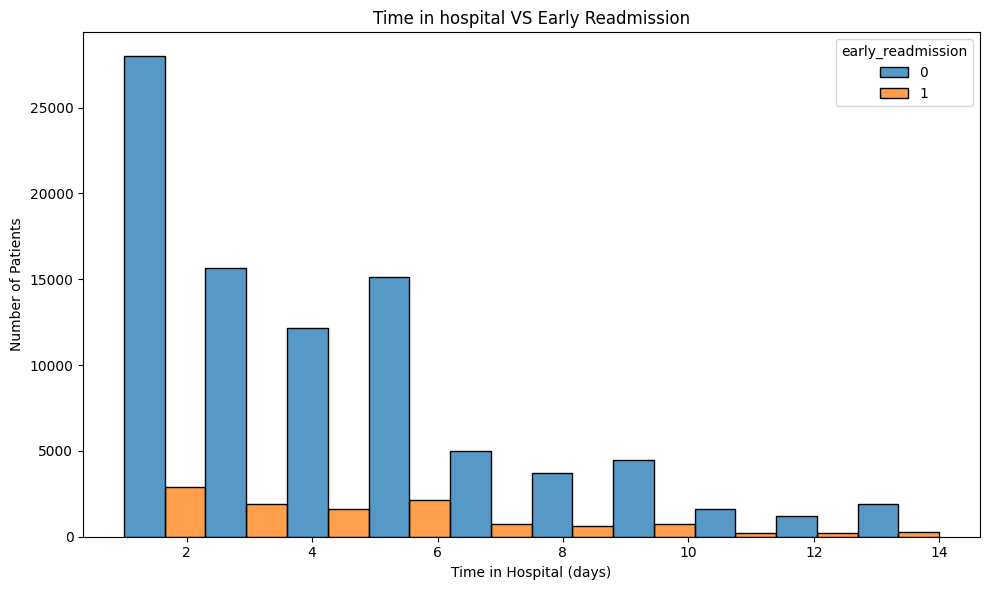

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='time_in_hospital',
    hue='early_readmission',
    bins=10,
    multiple='dodge',
    stat='count'
)

plt.xlabel('Time in Hospital (days)')
plt.ylabel('Number of Patients')
plt.title('Time in hospital VS Early Readmission')

plt.tight_layout()
plt.show()


Age and Readmission

Text(0.5, 1.0, 'Age of Patient VS. Readmission')

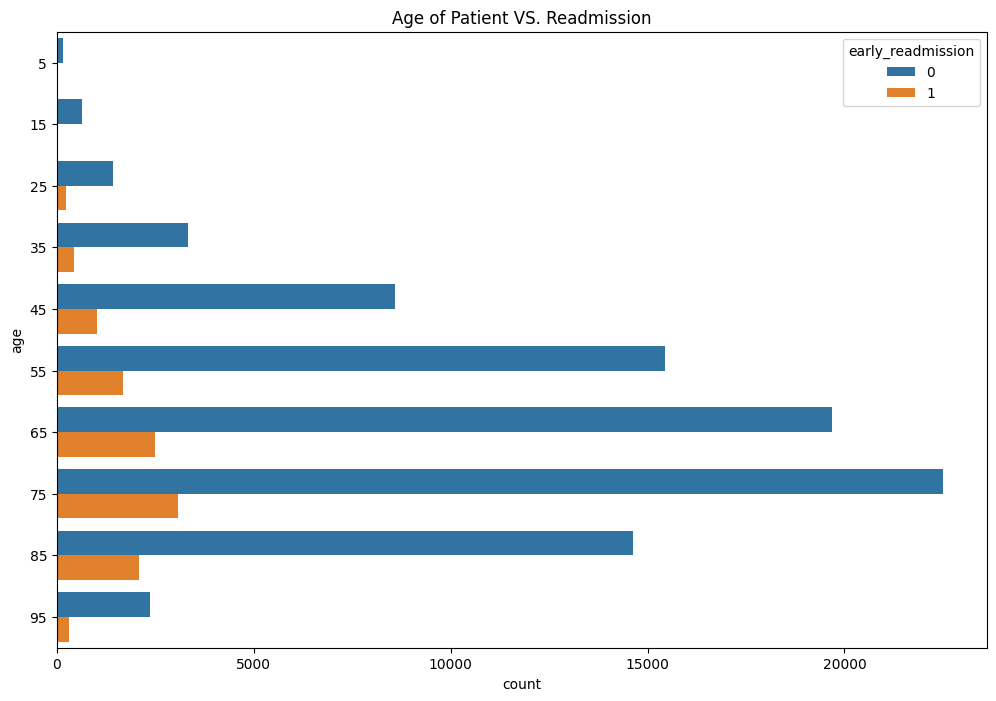

In [ ]:
fig = plt.figure(figsize=(12,8))
sns.countplot(y= df['age'], hue = df['early_readmission']).set_title('Age of Patient VS. Readmission')

Race Vs Readmission

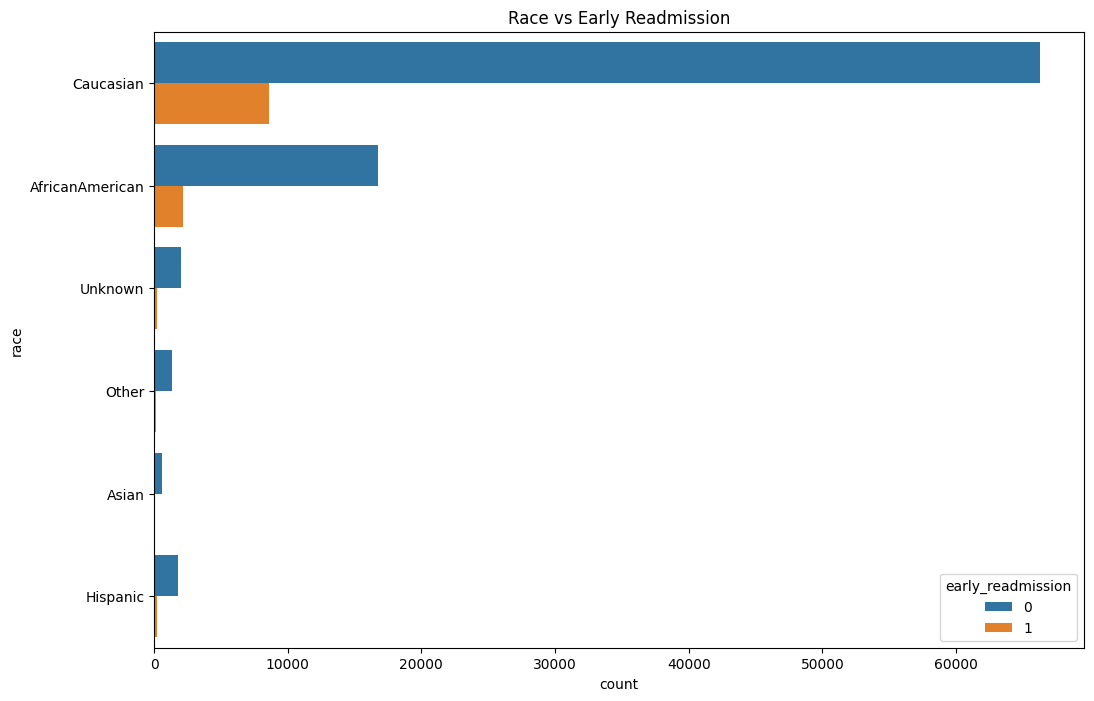

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(
    y='race',
    hue='early_readmission',
    data=df
)
plt.title('Race vs Early Readmission')
plt.show()


Gender VS Readmission

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,53866
Male,46255


In [ ]:
df_gender = df[df['gender'] != 'Unknown/Invalid']

In [ ]:
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'Male' else 0)


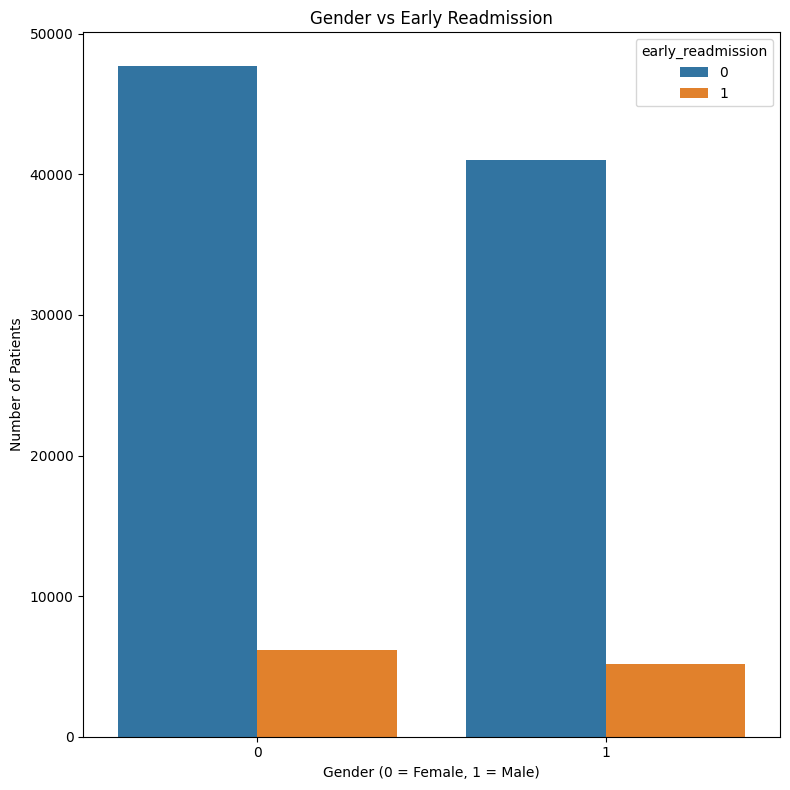

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    x='gender',
    hue='early_readmission'
)

plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')
plt.title('Gender vs Early Readmission')

plt.tight_layout()
plt.show()


Diabetes Medication prescribed and Readmission


Diabetes Medication - medications Nominal Indicates if there was any diabetic medication prescribed.


Values: “yes” : 1 “no” : 0:

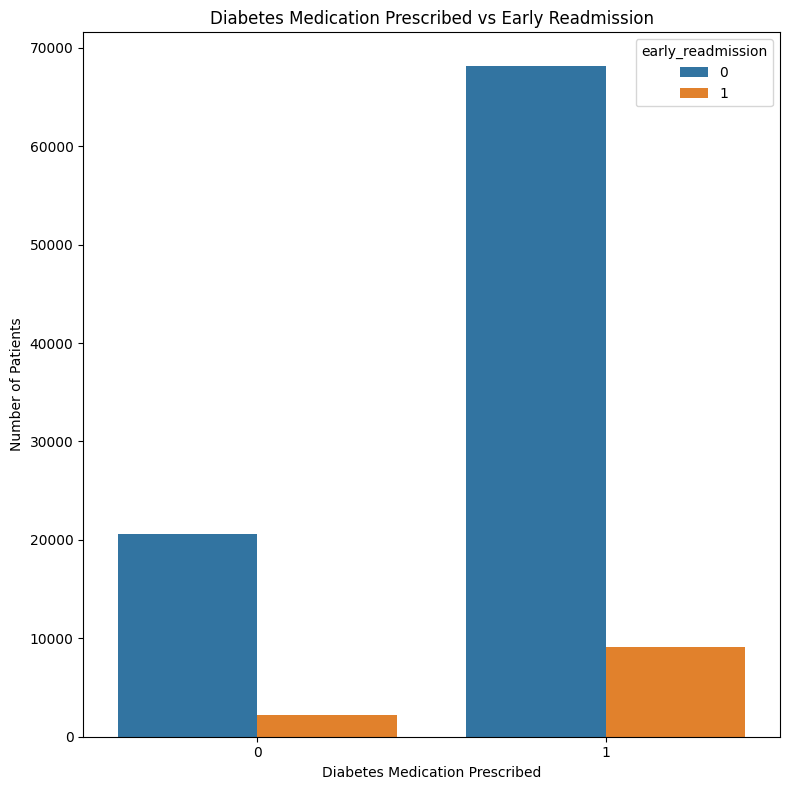

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    x='diabetesMed',
    hue='early_readmission'
)

plt.xlabel('Diabetes Medication Prescribed')
plt.ylabel('Number of Patients')
plt.title('Diabetes Medication Prescribed vs Early Readmission')

plt.tight_layout()
plt.show()


A1C result and Readmission A1C test - The A1C test is a blood test that provides information about your average levels of blood glucose, also called blood sugar, over the past 3 months.

'>7' : 2

'>8' : 2

Norm : 1= Normal

None : 0 = Test was not taken

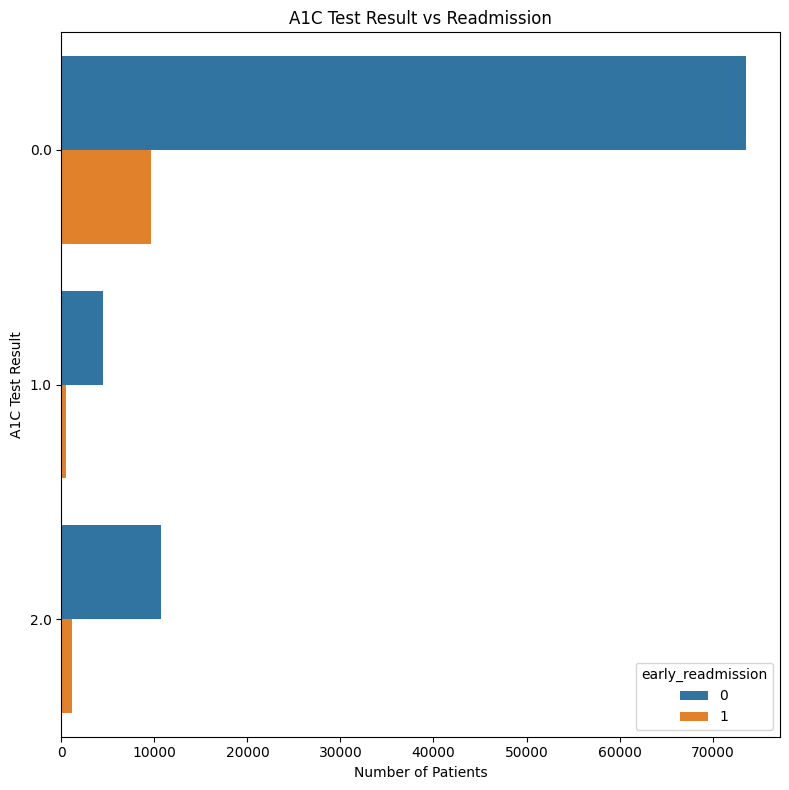

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    y='A1C_level',
    hue='early_readmission'
)

plt.xlabel('Number of Patients')
plt.ylabel('A1C Test Result')
plt.title('A1C Test Result vs Readmission')

plt.tight_layout()
plt.show()


## Class Imbalance Analysis

Early readmissions are much fewer than non-early readmissions, showing class imbalance.


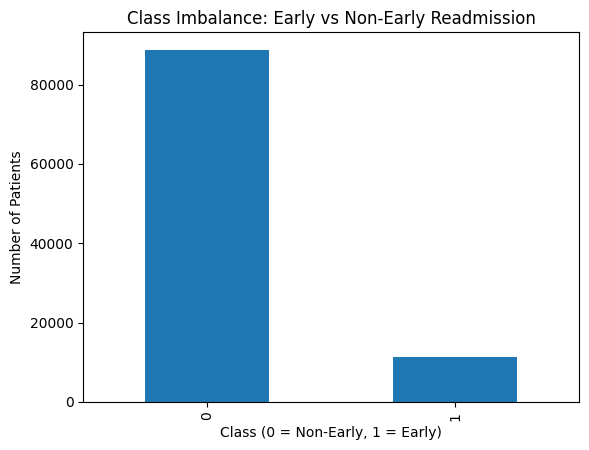

In [ ]:
import matplotlib.pyplot as plt

df['early_readmission'].value_counts().plot(kind='bar')
plt.xlabel('Class (0 = Non-Early, 1 = Early)')
plt.ylabel('Number of Patients')
plt.title('Class Imbalance: Early vs Non-Early Readmission')
plt.show()

# OUTLIER HANDLING


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100121 entries, 0 to 101765
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   race                       100121 non-null  object 
 1   gender                     100121 non-null  int64  
 2   age                        100121 non-null  int64  
 3   time_in_hospital           100121 non-null  int64  
 4   num_lab_procedures         100121 non-null  int64  
 5   num_procedures             100121 non-null  int64  
 6   num_medications            100121 non-null  int64  
 7   number_outpatient          100121 non-null  int64  
 8   number_emergency           100121 non-null  int64  
 9   number_inpatient           100121 non-null  int64  
 10  diag_1                     100121 non-null  object 
 11  diag_2                     100121 non-null  object 
 12  diag_3                     100121 non-null  object 
 13  number_diagnoses           100121 

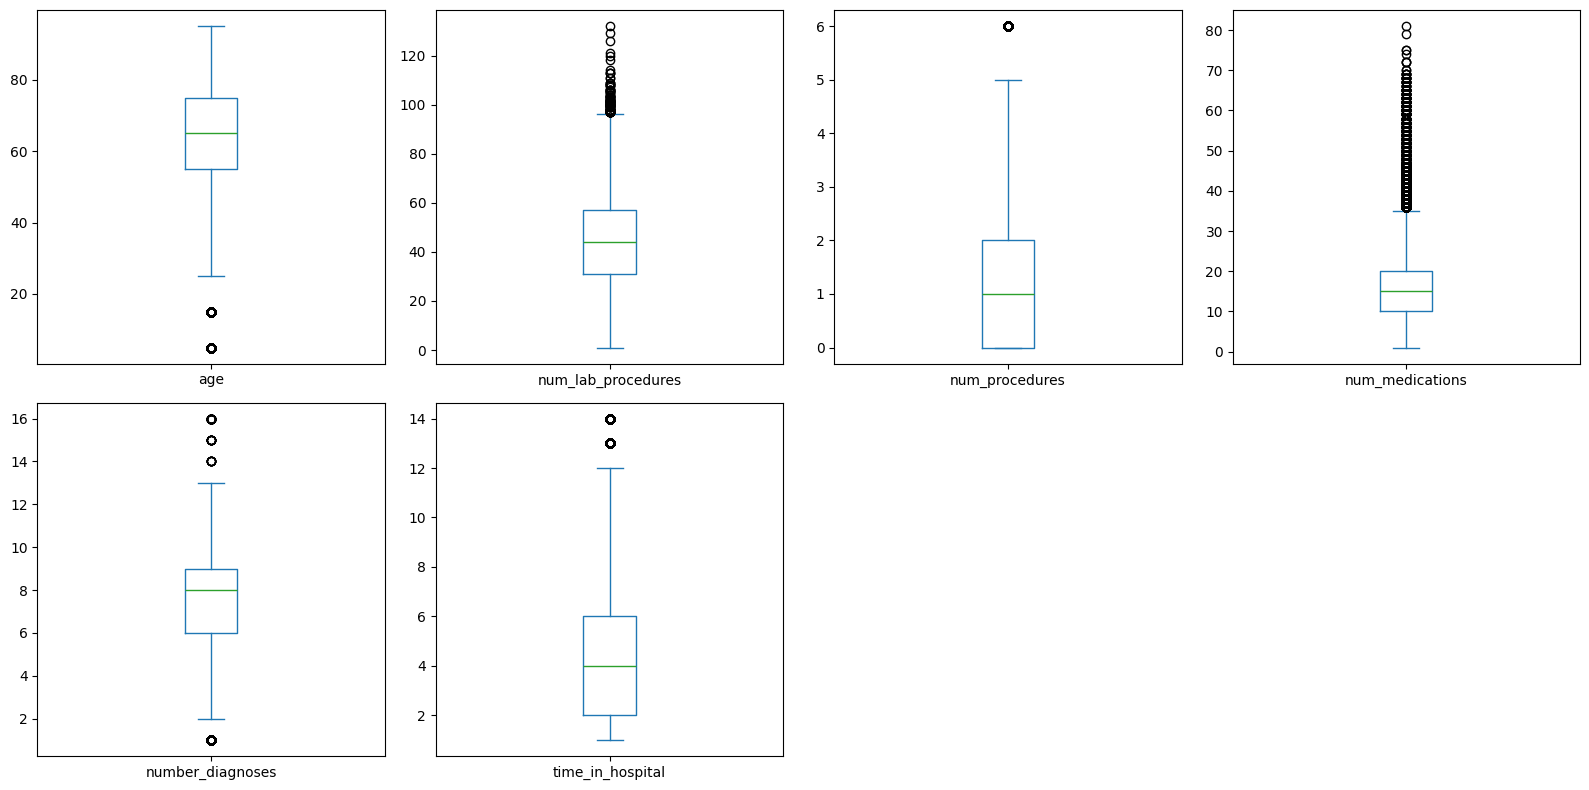

In [ ]:
# List of your specific columns
cols = ['age', 'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_diagnoses','time_in_hospital']

# One-line command for 8 subplots
df[cols].plot(kind='box', subplots=True, layout=(2,4), figsize=(16,8), sharex=False)
plt.tight_layout()
plt.show()

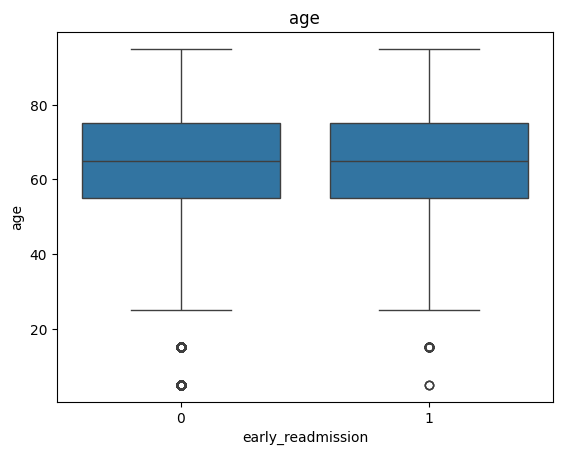

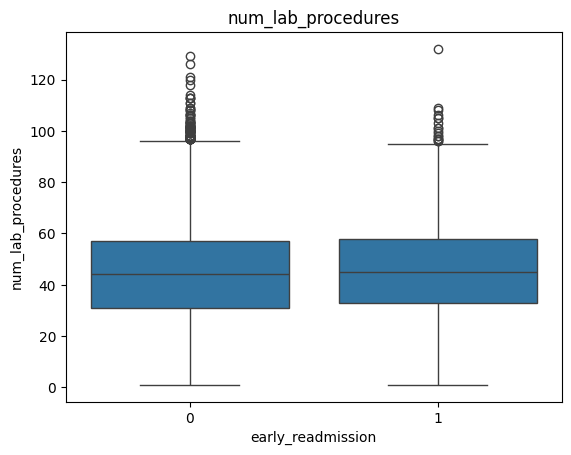

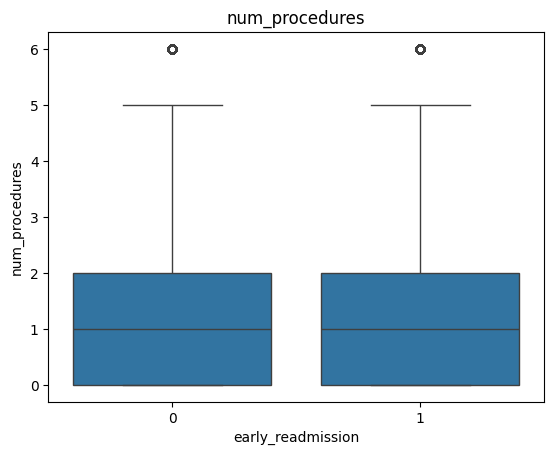

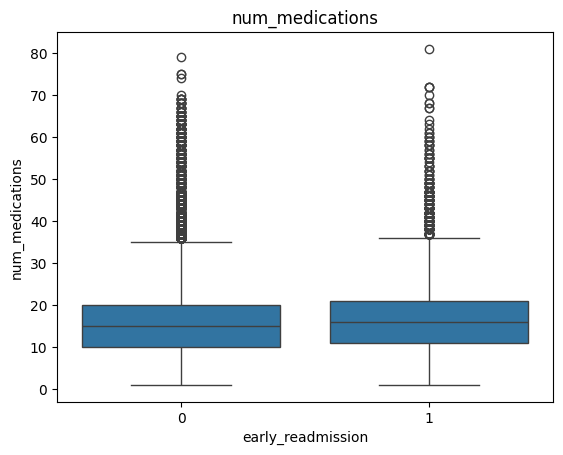

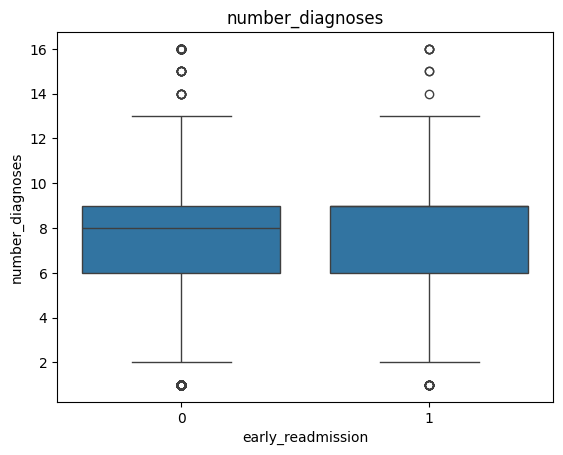

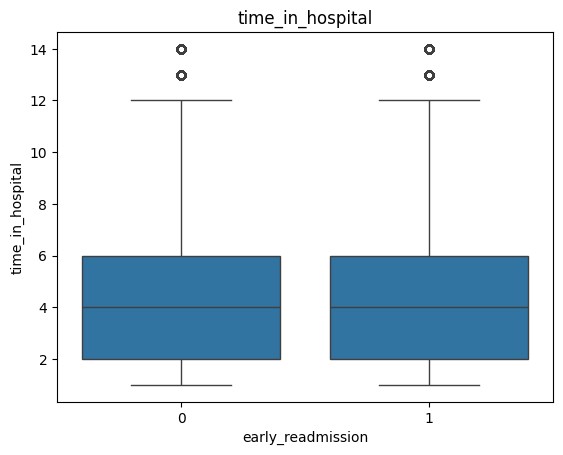

In [ ]:
for col in cols:
    sns.boxplot(x='early_readmission', y=col, data=df)
    plt.title(col)
    plt.show()

In [ ]:
df.describe()

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,early_readmission,A1C_measured,A1C_level,max_glu_serum_level,max_glu_serum_measured
count,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000
mean,0.461991,65.831794,4.389479,42.943369,1.330810,15.981532,0.369423,0.198340,0.632824,7.409315,0.463869,0.771826,0.113433,0.168566,0.287772,0.090760,0.052187
std,0.498556,15.947417,2.974524,19.620578,1.700327,8.092574,1.263968,0.935512,1.261819,1.938216,0.498695,0.419657,0.317123,0.374370,0.665864,0.428791,0.222405
min,0.000000,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,95.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000


In [ ]:
# Handled outliers by capping
#NOTE:Not treating age & num_diagnoses outliers
#age->Demographic information  num_diagnoses->clinical Complexity(high counts are critical health predictors, not noise.)
target_cols = ['num_medications', 'time_in_hospital', 'num_lab_procedures', 'num_procedures']

for col in target_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR


    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print(df.shape)

(100121, 24)


In [ ]:
df.describe()

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,early_readmission,A1C_measured,A1C_level,max_glu_serum_level,max_glu_serum_measured
count,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000
mean,0.461991,65.831794,4.357527,42.935838,1.282748,15.771467,0.369423,0.198340,0.632824,7.409315,0.463869,0.771826,0.113433,0.168566,0.287772,0.090760,0.052187
std,0.498556,15.947417,2.882403,19.597649,1.577353,7.368233,1.263968,0.935512,1.261819,1.938216,0.498695,0.419657,0.317123,0.374370,0.665864,0.428791,0.222405
min,0.000000,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,95.000000,12.000000,96.000000,5.000000,35.000000,42.000000,76.000000,21.000000,16.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000





#Feature Re-Engineering


In [ ]:
# ---------------------------------------------------
# Interaction Features
# These capture combined effects of multiple risk factors
# ---------------------------------------------------

# Older patients with longer hospital stays are more likely to be readmitted
# df['age_x_time'] = df['age'] * df['time_in_hospital']
# ==> removed as it can imply only older ppl with long stays are risky

# combination of elderly + long stay more useful
# Long hospital stay (1 week or more) ==> signals omplications
df['long_stay'] = (df['time_in_hospital'] >= 7).astype(int)

# Elderly patients (higher readmission risk)
df['elderly'] = (df['age'] >= 65).astype(int)

df.drop(columns=['time_in_hospital','age'], inplace=True)

In [ ]:
# ---------------------------------------------------
# Disease Burden Index
# Combines diagnoses and procedures to reflect illness complexity
# ---------------------------------------------------

# higher the burden, higher the odds of early admission
df['disease_burden'] = (
    df['number_diagnoses'] +
    df['num_procedures']
)

# Clinical complexity: lab tests increase with number of diagnoses
#df['lab_x_diag'] = df['num_lab_procedures'] * df['number_diagnoses']
# ==> removed because its difficult to interpret the change (exp(b))

df['complex_case'] = (
    (df['number_diagnoses'] >= 5) &
    (df['num_lab_procedures'] >= 50)
).astype(int)

df.drop(columns=['number_diagnoses','num_procedures','num_lab_procedures'], inplace=True)

Binary High-Risk Flags helps logistic regression learn threshold-based risk.
These indicate clinically meaningful risk thresholds


In [ ]:
#Treatment Burden & instability
# patient on many meds + dosage changes == unstable condition or poor control

# Polypharmacy: patient taking many medications
df['polypharmacy'] = (df['num_medications'] >= 10).astype(int)

# Medication instability: many medications + dosage change
# df['med_x_change'] = df['num_medications'] * df['change']

# instead of a product (numerical), we can create a flag for med instability:
df['unstable_med'] = ((df['num_medications'] >= 10) &
                        (df['change'] == 1)).astype(int)

df.drop(columns=['num_medications','change'], inplace=True)


In [ ]:
#how often the patient needed medical care before the current admission.
# frequent past care == unresolved chronic issues
df['total_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)

# patients who are inpatient-heavy are more likely to early readmission
df['inpatient_ratio'] = df['number_inpatient'] / (df['total_visits'] + 1)

df.drop(columns=['number_outpatient','number_emergency','number_inpatient'], inplace= True)

In [ ]:
# diabetes focused patients flag

df['diabetes_any_diag'] = (
    (df['diag_1'] == 'Diabetes') |
    (df['diag_2'] == 'Diabetes') |
    (df['diag_3'] == 'Diabetes')
).astype(int)

df.drop(columns=['diag_2','diag_3'], inplace=True)

In [ ]:
df.columns

Index(['race', 'gender', 'diag_1', 'diabetesMed', 'early_readmission',
       'medical_specialty_grouped', 'A1C_measured', 'A1C_level',
       'max_glu_serum_level', 'max_glu_serum_measured',
       'admission_type_grouped', 'admission_source_grouped', 'long_stay',
       'elderly', 'disease_burden', 'complex_case', 'polypharmacy',
       'unstable_med', 'total_visits', 'inpatient_ratio', 'diabetes_any_diag'],
      dtype='object')

# One Hot Encoding

In [ ]:
df.dtypes

,0
race,object
gender,int64
diag_1,object
diabetesMed,int64
early_readmission,int64
medical_specialty_grouped,object
A1C_measured,int64
A1C_level,float64
max_glu_serum_level,float64
max_glu_serum_measured,int64


In [ ]:
df.describe()

,gender,diabetesMed,early_readmission,A1C_measured,A1C_level,max_glu_serum_level,max_glu_serum_measured,long_stay,elderly,disease_burden,complex_case,polypharmacy,unstable_med,total_visits,inpatient_ratio,diabetes_any_diag
count,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000,100121.000000
mean,0.461991,0.771826,0.113433,0.168566,0.287772,0.090760,0.052187,0.206550,0.670469,8.692063,0.358736,0.798094,0.408526,1.200587,0.169600,0.377144
std,0.498556,0.419657,0.317123,0.374370,0.665864,0.428791,0.222405,0.404832,0.470045,2.581340,0.479632,0.401424,0.491564,2.292719,0.257464,0.484674
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,1.000000,1.000000,1.000000,2.000000,0.500000,1.000000
max,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,21.000000,1.000000,1.000000,1.000000,80.000000,0.950000,1.000000


In [ ]:
# Identify numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Get the maximum value for each numerical column
max_values = numeric_df.max()

# Filter columns where the maximum value is greater than 1
numeric_cols = max_values[max_values != 1].index.tolist()

# Display descriptive statistics for the filtered columns
print(df[numeric_cols].describe())

           A1C_level  max_glu_serum_level  disease_burden   total_visits  \
count  100121.000000        100121.000000   100121.000000  100121.000000   
mean        0.287772             0.090760        8.692063       1.200587   
std         0.665864             0.428791        2.581340       2.292719   
min         0.000000             0.000000        1.000000       0.000000   
25%         0.000000             0.000000        7.000000       0.000000   
50%         0.000000             0.000000        9.000000       0.000000   
75%         0.000000             0.000000       10.000000       2.000000   
max         2.000000             3.000000       21.000000      80.000000   

       inpatient_ratio  
count    100121.000000  
mean          0.169600  
std           0.257464  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           0.500000  
max           0.950000  


In [ ]:
categorical_cols = [
    'race',
    'medical_specialty_grouped',
    'diag_1',
    'admission_type_grouped',
    'admission_source_grouped'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
df.dtypes

,0
gender,int64
diabetesMed,int64
early_readmission,int64
A1C_measured,int64
A1C_level,float64
max_glu_serum_level,float64
max_glu_serum_measured,int64
long_stay,int64
elderly,int64
disease_burden,int64


In [ ]:
#convert all to int type features
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.dtypes

,0
gender,int64
diabetesMed,int64
early_readmission,int64
A1C_measured,int64
A1C_level,float64
max_glu_serum_level,float64
max_glu_serum_measured,int64
long_stay,int64
elderly,int64
disease_burden,int64


## Define Train and Target Variables

In [ ]:
# input and target in x and y
X = df.drop(columns=['early_readmission'])
y = df['early_readmission']

# ASSUMPTION CHECKING FOR LR

## 1. Linearity with Log Odds

Categorical variables have been one-hot encoded and became binary (only have values 0 and 1) ==> they cannot form a curve, thus no linearity assumption checking required as they are already discreet.

On the other hand, Numerical variables can take a range of values which is why we do lineaity with log odds test. The log-odds of the outcome should increase or decrease linearly with the numeric variable.

In [ ]:
print(numeric_cols)

['A1C_level', 'max_glu_serum_level', 'disease_burden', 'total_visits', 'inpatient_ratio']


In [ ]:
import statsmodels.api as sm
import numpy as np

# filter LR using continuous predictors
X_cont = X[numeric_cols]
# const is intercept (baseline log-odds of target when all predictors are 0)
X_cont = sm.add_constant(X_cont)
y = df['early_readmission']

model = sm.Logit(y, X_cont)
result = model.fit()


Optimization terminated successfully.
         Current function value: 0.342750
         Iterations 6


In [ ]:
# compute predicted log-odds
p = result.predict(X_cont)
p = np.clip(p, 1e-6, 1 - 1e-6)
df['logit'] = np.log(p / (1 - p))

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


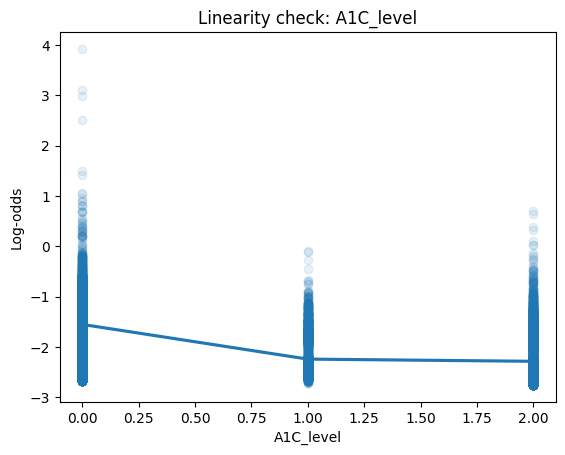

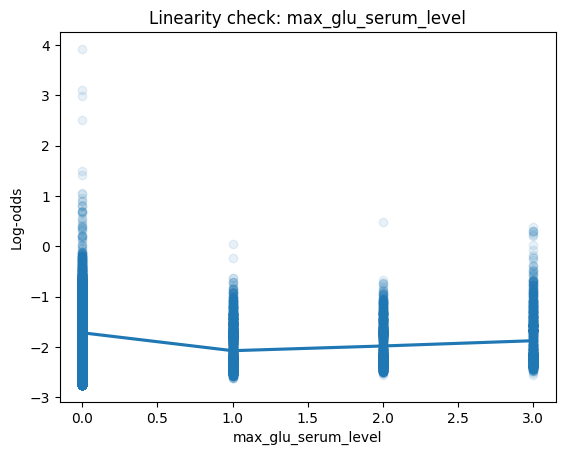

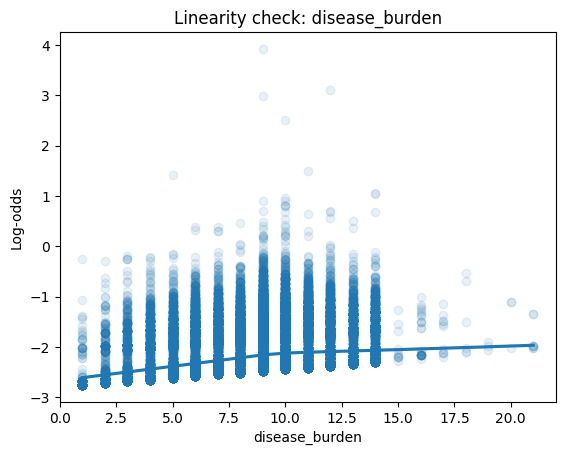

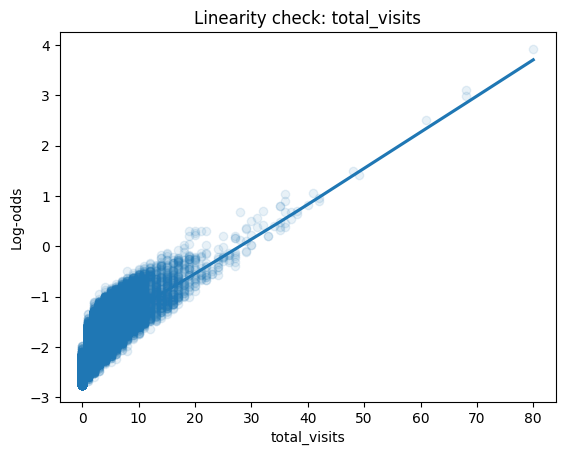

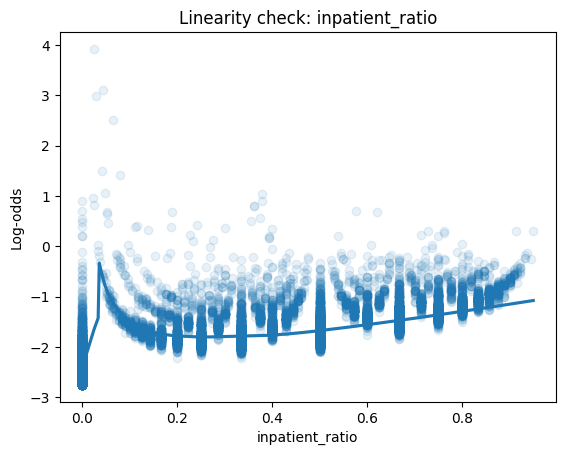

In [ ]:
# plot logit vs each continuous predictor
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    sns.regplot(x=df[col], y=df['logit'], lowess=True, scatter_kws={'alpha':0.1})
    plt.title(f'Linearity check: {col}')
    plt.xlabel(col)
    plt.ylabel('Log-odds')
    plt.show()


Interpretation:

Roughly straight with mild noise ==> linearity assumption satisfied

In [ ]:
df.drop(columns=['logit'], inplace=True)
print("\n=== Linearity check: Coefficients ===")
print(result.params)


=== Linearity check: Coefficients ===
const                 -2.705909
A1C_level             -0.040236
max_glu_serum_level    0.065245
disease_burden         0.034044
total_visits           0.078660
inpatient_ratio        1.134975
dtype: float64


coefficient = change in log-odds per unit increase, requires linearity check.

Magnitude matters:
- inpatient_ratio is clearly the strongest predictor; others are small but can still contribute.

Sign of coefficient:

- Positive → increases odds
- Negative → decreases odds

## 2. Multicollinearity

In [ ]:
# ---------------------------------------------------
# Fix data types before VIF calculation
# ---------------------------------------------------

# Keep only numeric columns
X_numeric = X[numeric_cols]
X_numeric.head()

,A1C_level,max_glu_serum_level,disease_burden,total_visits,inpatient_ratio
0,0.0,0.0,1,0,0.00
1,0.0,0.0,9,0,0.00
2,0.0,0.0,11,3,0.25
3,0.0,0.0,8,0,0.00
4,0.0,0.0,5,0,0.00


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create VIF table
vif_table = pd.DataFrame()
vif_table["Feature"] = X_numeric.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

# Sort by highest VIF
vif_table = vif_table.sort_values(by="VIF", ascending=False)

vif_table.head(10)

,Feature,VIF
4,inpatient_ratio,1.755975
2,disease_burden,1.689308
3,total_visits,1.588712
0,A1C_level,1.166328
1,max_glu_serum_level,1.039235


VIF< 10 ==> Multicollinearity doesn't exists

**Checking pair-wise Correlation**

                                               gender  diabetesMed  \
gender                                       1.000000     0.016717   
diabetesMed                                  0.016717     1.000000   
A1C_measured                                 0.019638     0.069416   
A1C_level                                    0.022659     0.082037   
max_glu_serum_level                         -0.002575     0.000911   
max_glu_serum_measured                      -0.002153    -0.019347   
long_stay                                   -0.014053     0.037722   
elderly                                     -0.030497    -0.003653   
disease_burden                               0.033284     0.009176   
complex_case                                -0.016011     0.036240   
polypharmacy                                -0.036674     0.175288   
unstable_med                                 0.001697     0.451872   
total_visits                                -0.023568     0.035694   
inpatient_ratio     

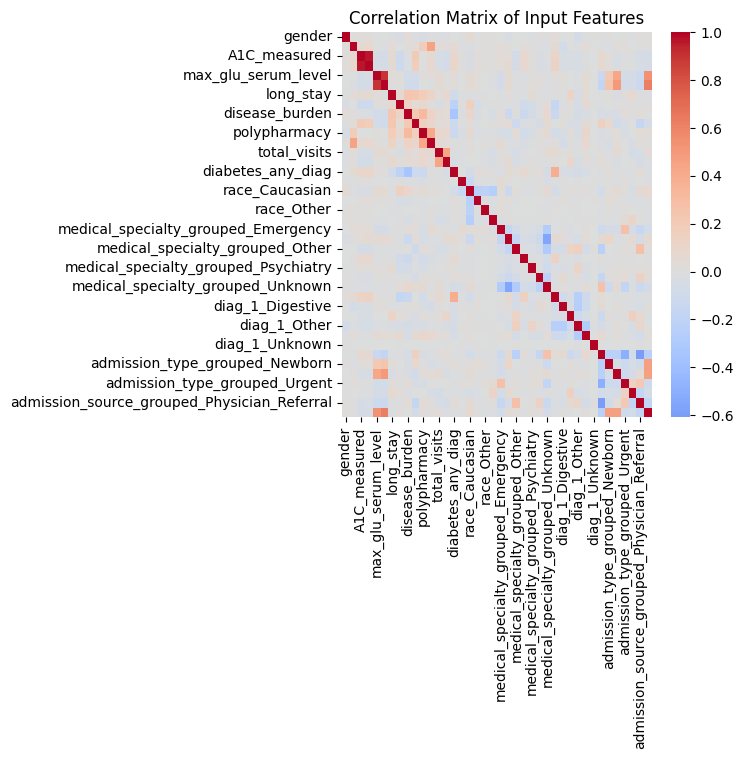

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix of inputs only
corr_inputs = X.corr()

print(corr_inputs)

# Heatmap
plt.figure(figsize=(5,5))
sns.heatmap(corr_inputs, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Input Features")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Correlation matrix (already computed)
corr_inputs = X.corr()

# Take only upper triangle (no duplicates, no self-correlation)
upper_triangle = corr_inputs.where(
    np.triu(np.ones(corr_inputs.shape), k=1).astype(bool)
)

# Convert to proper table format
corr_table = upper_triangle.unstack().dropna().reset_index()
corr_table.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Sort by highest correlation
corr_table = corr_table.sort_values(by='Correlation', key=abs, ascending=False)

print(corr_table.head(20))   # Top 20 correlations

                                       Feature 1  \
5                                      A1C_level   
14                        max_glu_serum_measured   
746            admission_source_grouped_Transfer   
736  admission_source_grouped_Physician_Referral   
346            medical_specialty_grouped_Unknown   
745            admission_source_grouped_Transfer   
663                admission_type_grouped_Urgent   
600                 admission_type_grouped_Other   
775            admission_source_grouped_Transfer   
776            admission_source_grouped_Transfer   
56                                  unstable_med   
90                               inpatient_ratio   
599                 admission_type_grouped_Other   
65                                  unstable_med   
365                              diag_1_Diabetes   
99                             diabetes_any_diag   
53                                  polypharmacy   
347            medical_specialty_grouped_Unknown   
725  admissi

**Before feature re-engineering:**

Although many predictors have high VIF values, pairwise correlations are moderate to low indicating distributed multicollinearity rather than redundancy between specific variables

**After re-engineering:**

VIF<5 ==> Safe
Checked correlation as a diagnostic measure and found high correlation between measured and level ==> one encodes the other so dropping measured would be better

In [ ]:
df.drop(columns=['max_glu_serum_level','A1C_level'], inplace=True)
X.drop(columns=['max_glu_serum_level','A1C_level'], inplace=True)
X_numeric.drop(columns=['max_glu_serum_level','A1C_level'], inplace=True)


/tmp/ipython-input-1736157339.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_numeric.drop(columns=['max_glu_serum_level','A1C_level'], inplace=True)


In [ ]:
numeric_cols.remove('max_glu_serum_level')
numeric_cols.remove('A1C_level')

## 3. Binary target

In [ ]:
df['early_readmission'].value_counts()

,count
early_readmission,
0,88764
1,11357


## Sufficient sample size per variable

In [ ]:
n_events = df['early_readmission'].sum()
print("Total early admissions",n_events)
n_predictors = X.shape[1]
print("Total predictors (X cols): ",n_predictors)
epv = n_events / n_predictors
print("Events per variable",epv)

Total early admissions 11357
Total predictors (X cols):  38
Events per variable 298.86842105263156


==> Rule of thumb for sample size:
10 events per predictor minimum.

we have 299 (approx) which is more than good!

# INFERENTIAL STATISTICS

**Null Hypothesis**: Model has no predictive power

- βi = 0


**Alternate Hypothesis**: Model is statistically significant.


- atleast one coefficient (βi) != 0


In [ ]:
# we use all columns
import statsmodels.api as sm

X_sm = sm.add_constant(X)   # ALL predictors
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.341151
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      early_readmission   No. Observations:               100121
Model:                          Logit   Df Residuals:                   100082
Method:                           MLE   Df Model:                           38
Date:                Fri, 13 Feb 2026   Pseudo R-squ.:                 0.03530
Time:                        03:44:24   Log-Likelihood:                -34156.
converged:                       True   LL-Null:                       -35406.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                     

(Likelihood Ratio Test) LLR p-value = 0

==> predictors collectively improve model fir comare to a null model with no predictors. Thus, we reject the null hypothesis

Log-Likelihood:                -34156 > LL-Null:                       -35406.

==> Full model improved performance

Pseudo R-squ.:                 0.03530 = 3.5% improvement over null model

==> modest explanatory power, but expected in clinical readmission models where outcomes depend on multifactorial influences beyond recorded variables

In [ ]:
#converting log-odds to odds ratio
import numpy as np

np.exp(result.params)

,0
const,0.037917
gender,1.007241
diabetesMed,1.155756
A1C_measured,0.884211
max_glu_serum_measured,1.260110
long_stay,1.114729
elderly,1.169302
disease_burden,1.023345
complex_case,1.059057
polypharmacy,1.118634


In [ ]:
conf = result.conf_int()
np.exp(conf)

,0,1
const,0.031743,0.045292
gender,0.967630,1.048473
diabetesMed,1.093410,1.221658
A1C_measured,0.834491,0.936893
max_glu_serum_measured,1.122148,1.415035
long_stay,1.060171,1.172095
elderly,1.117073,1.223973
disease_burden,1.013888,1.032890
complex_case,1.012484,1.107772
polypharmacy,1.051796,1.189719


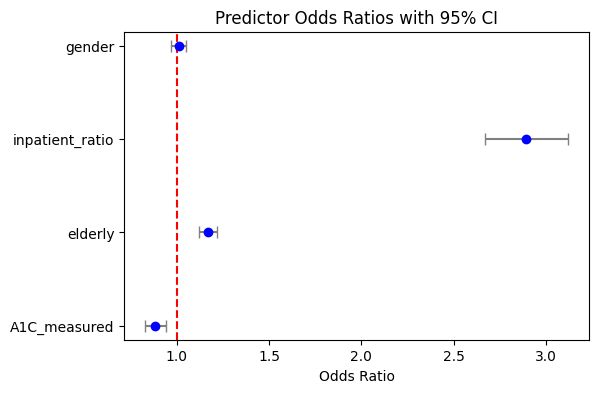

In [ ]:
import matplotlib.pyplot as plt

# Example DataFrame
df_or = pd.DataFrame({
    'predictor': ['gender', 'inpatient_ratio', 'elderly', 'A1C_measured'],
    'OR': [1.01, 2.89, 1.17, 0.88],
    'CI_lower': [0.97, 2.67, 1.12, 0.83],
    'CI_upper': [1.05, 3.12, 1.22, 0.94]
})

plt.figure(figsize=(6,4))
plt.errorbar(df_or['OR'], df_or['predictor'],
             xerr=[df_or['OR']-df_or['CI_lower'], df_or['CI_upper']-df_or['OR']],
             fmt='o', color='blue', ecolor='gray', capsize=4)
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Odds Ratio')
plt.title('Predictor Odds Ratios with 95% CI')
plt.gca().invert_yaxis()
plt.show()

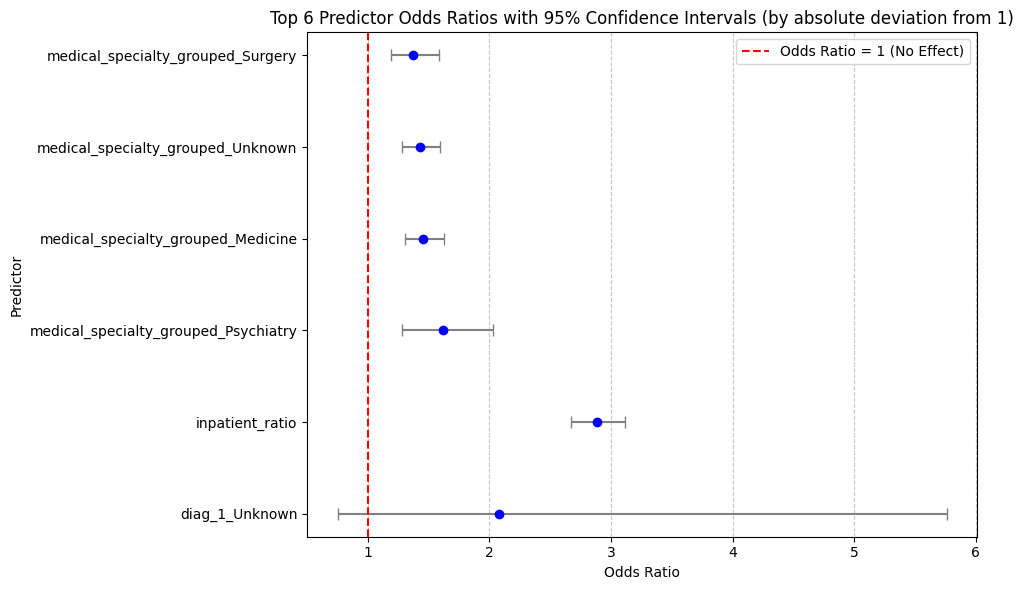

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a DataFrame for Odds Ratios and their Confidence Intervals
df_odds = pd.DataFrame({
    'Odds_Ratio': np.exp(result.params),
    'CI_lower': np.exp(result.conf_int()[0]),
    'CI_upper': np.exp(result.conf_int()[1])
})

# Filter out the 'const' term and sort by Odds_Ratio for plotting
df_odds = df_odds.drop('const').sort_values(by='Odds_Ratio', ascending=True)

# Calculate a 'diff' column for sorting by absolute deviation from 1
df_odds['diff'] = abs(df_odds['CI_lower'] - 1) + abs(df_odds['CI_upper'] - 1)

# Plot top 6 ORs by absolute deviation from 1
# Sort by 'diff' to get the most impactful predictors (farthest from 1)
# and then select the head (top 6).
plot_df = df_odds.sort_values('diff', ascending=False).head(6)

plt.figure(figsize=(10, 6))
plt.errorbar(
    plot_df['Odds_Ratio'], plot_df.index,
    xerr=[plot_df['Odds_Ratio'] - plot_df['CI_lower'], plot_df['CI_upper'] - plot_df['Odds_Ratio']],
    fmt='o', color='blue', ecolor='gray', capsize=4
)
plt.axvline(x=1, color='red', linestyle='--', label='Odds Ratio = 1 (No Effect)')
plt.xlabel('Odds Ratio')
plt.ylabel('Predictor')
plt.title('Top 6 Predictor Odds Ratios with 95% Confidence Intervals (by absolute deviation from 1)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# MODELLING

##Train–Test Split

In [ ]:
# Stratify to preserve class imbalance

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

##Feature Scaling

In [ ]:
# Feature Scaling for Logistic Regression
# Standardize continuous variables to mean=0, std=1

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

In [ ]:
# Feature Scaling (Train-only fit to prevent leakage)

# Fit scaler ONLY on training data
X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Apply same transformation to test data
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


# Logistic Regression Model


## VARIANT 1: BASELINE MODEL

In [ ]:
# Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,              # ensures convergence
    class_weight='balanced',    # handles class imbalance
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Make predictions on test data

In [ ]:
# Predict on Test Data

# Predicted class labels (0/1)
y_pred = log_reg.predict(X_test_scaled)

# Predicted probabilities (for ROC-AUC)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

Confusion Matrix

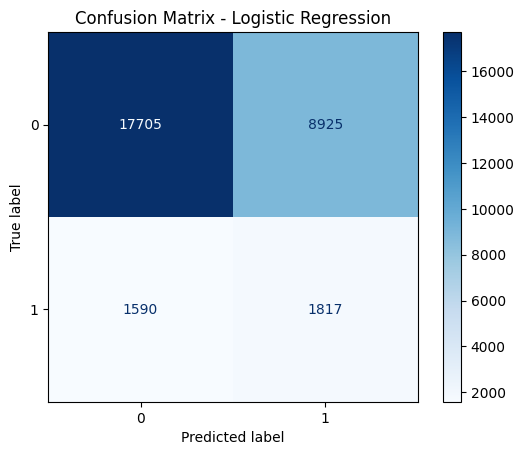

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [ ]:
#print confusion matrix
print(cm)

[[17705  8925]
 [ 1590  1817]]


To Miss a patient who will be readmitted (False Negative)  is worse than
to Flag a patient who won’t be readmitted (False Positive)

==> Priority is:

1. **Recall (Sensitivity)= ability to detect true early readmissions.**

2. F1 Score - we don't want high false alarms either

Classification Report

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.66      0.77     26630
           1       0.17      0.53      0.26      3407

    accuracy                           0.65     30037
   macro avg       0.54      0.60      0.51     30037
weighted avg       0.83      0.65      0.71     30037



Model tries to catch many positives → recall 53%

But it produces many false positives → precision 17%

ROC Curve and AUC

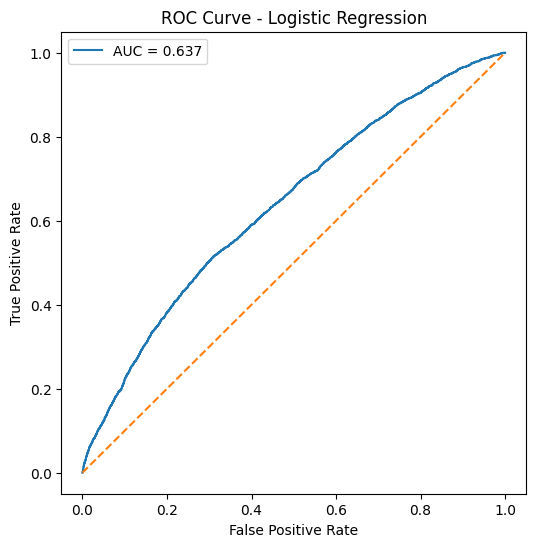

In [ ]:
# ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()




Threshold tuning

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = np.arange(0.1, 0.8, 0.05)

for t in thresholds:
    y_pred_tuned = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_tuned))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     26630
           1       0.11      1.00      0.20      3407

    accuracy                           0.11     30037
   macro avg       0.06      0.50      0.10     30037
weighted avg       0.01      0.11      0.02     30037


Threshold: 0.15000000000000002
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     26630
           1       0.11      1.00      0.20      3407

    accuracy                           0.11     30037
   macro avg       0.56      0.50      0.10     30037
weighted avg       0.90      0.11      0.02     30037


Threshold: 0.20000000000000004
              precision    recall  f1-score   support

           0       0.99      0.00      0.01     26630
           1       0.11      1.00      0.20      3407

    accuracy                           0.12     30037
   macro avg       0.55      0.50      0.10     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Compute FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute distance to top-left corner (0,1) for each threshold
distances = np.sqrt((fpr - 0)**2 + (1 - tpr)**2)

# Find threshold with minimum distance
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

# Optional: compute ROC AUC
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

Optimal Threshold: 0.4765067012005391
ROC AUC: 0.6371921595451745


In [ ]:
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

[[16038 10592]
 [ 1400  2007]]
              precision    recall  f1-score   support

           0       0.92      0.60      0.73     26630
           1       0.16      0.59      0.25      3407

    accuracy                           0.60     30037
   macro avg       0.54      0.60      0.49     30037
weighted avg       0.83      0.60      0.67     30037



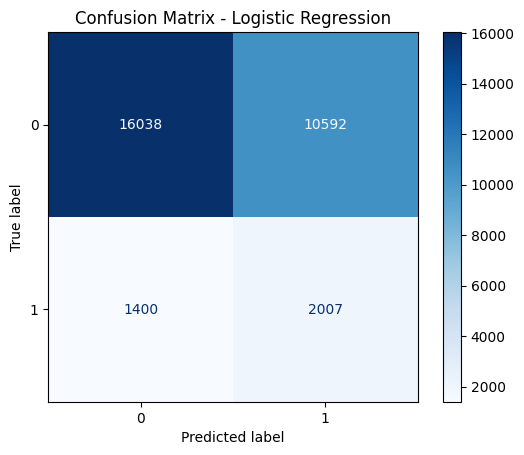

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

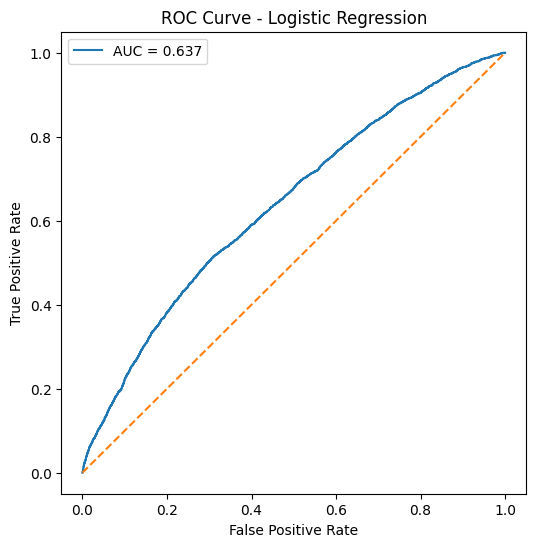

In [ ]:
# ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Interpret model coefficients

In [ ]:
# ---------------------------------------------------
# Feature Importance (Logistic Regression Coefficients)
# ---------------------------------------------------

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)

coef_df.head(10)


,Feature,Coefficient,Odds_Ratio
22,medical_specialty_grouped_Psychiatry,0.423188,1.526821
24,medical_specialty_grouped_Unknown,0.364855,1.440305
19,medical_specialty_grouped_Medicine,0.333276,1.395532
23,medical_specialty_grouped_Surgery,0.305575,1.357406
3,max_glu_serum_measured,0.282175,1.326011
18,medical_specialty_grouped_Emergency,0.258861,1.295454
20,medical_specialty_grouped_Other,0.258822,1.295403
11,inpatient_ratio,0.250462,1.284618
10,total_visits,0.206606,1.229499
5,elderly,0.181122,1.198561


## Variant 2: CV

nstead of training once, cross-validation splits the data into 5 folds, trains the model on 4 folds, and tests on the remaining fold, repeating this for all folds.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np
from sklearn.pipeline import Pipeline

# optimal threshold from previous tuning
optimal_threshold = 0.4765


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Get cross-validated predicted probabilities
y_proba_cv = cross_val_predict(
    pipeline, X, y, cv=5, method='predict_proba'
)[:, 1]  # probability of class 1

# Apply threshold
y_pred_cv = (y_proba_cv >= optimal_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)
print("Cross-validated Confusion Matrix:")
print(cm)

# Classification report
report = classification_report(y, y_pred_cv)
print("\nCross-validated Classification Report:")
print(report)

# ROC AUC
roc = roc_auc_score(y, y_proba_cv)
print(f"\nCross-validated ROC AUC: {roc:.3f}")


Cross-validated Confusion Matrix:
[[53740 35024]
 [ 4685  6672]]

Cross-validated Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.61      0.73     88764
           1       0.16      0.59      0.25     11357

    accuracy                           0.60    100121
   macro avg       0.54      0.60      0.49    100121
weighted avg       0.83      0.60      0.68    100121


Cross-validated ROC AUC: 0.634


# RANDOM FOREST

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     26630
           1       0.17      0.54      0.25      3407

    accuracy                           0.64     30037
   macro avg       0.54      0.60      0.51     30037
weighted avg       0.83      0.64      0.71     30037

Confusion Matrix:

[[17422  9208]
 [ 1577  1830]]
ROC-AUC Score: 0.6371302770543428


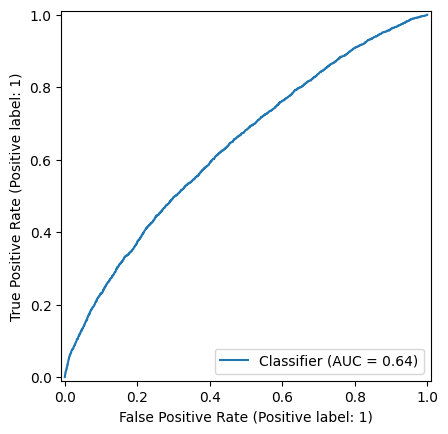

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt

# --- Feature Selection using Random Forest importance ---
selector_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_train, y_train)

selector = SelectFromModel(selector_model, threshold="median", prefit=True)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

# --- Final Random Forest Model ---
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sel, y_train)

# --- Predictions ---
y_pred = rf.predict(X_test_sel)
y_prob = rf.predict_proba(X_test_sel)[:, 1]

# --- Evaluation ---
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

In [ ]:
import pandas as pd

# Get feature importances from the trained Random Forest model
feature_importances = rf.feature_importances_

# Get the names of the selected features
# We need to map back to the original feature names before selection
selected_features_mask = selector.get_support()
selected_feature_names = X.columns[selected_features_mask]

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
print(importance_df.head(10))


Random Forest Feature Importances:
                              Feature  Importance
9                     inpatient_ratio    0.410777
8                        total_visits    0.309349
5                      disease_burden    0.057447
4                             elderly    0.042398
3                           long_stay    0.032720
7                        unstable_med    0.020351
1                         diabetesMed    0.019837
6                        complex_case    0.014616
13  medical_specialty_grouped_Unknown    0.012589
14                       diag_1_Other    0.011570
